# Variational Autoencoders on MNIST
## Generative Modeling of Handwritten Digits

**MAT 4953/6973 — Mathematical Foundations of AI** (Spring 2026, UTSA)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/MathAIspring2026UTSA/blob/main/code/vae_mnist.ipynb)

---

This notebook is a **companion** to [MNIST feedforward classification](intro_feedforward_mnist.ipynb) and [Generative Models](generative_models.ipynb). Where the feedforward network *classifies* digits (discriminative), a **Variational Autoencoder (VAE)** *generates* new digits by learning the underlying data distribution (generative).

By the end of this notebook you will have:
- Trained a VAE on the 60,000 MNIST training images.
- Visualized how well the VAE **reconstructs** held-out test digits.
- **Sampled new digits** never seen during training by drawing $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, I)$ and decoding.
- Explored the **2-D latent space** the model learns (with `latent_dim = 2`).

**Prerequisites:** [Feedforward MNIST](intro_feedforward_mnist.ipynb) for Keras basics; [Generative Models](generative_models.ipynb) for the full VAE mathematics.

---
# 0. Setup

Run the cell below first. It auto-detects the runtime (Colab TPU/GPU or local CPU),
sets the JAX backend, and imports all dependencies.

In [1]:
# @title Runtime & backend setup (run first)
import os, subprocess, platform

def _detect_platform():
    try:
        import requests
        r = requests.get('http://metadata.google.internal/computeMetadata/v1/instance/attributes/tpu-name',
                         headers={'Metadata-Flavor': 'Google'}, timeout=2)
        if r.ok: return 'tpu'
    except Exception: pass
    try:
        res = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
                             capture_output=True, text=True, timeout=5)
        if res.returncode == 0 and res.stdout.strip(): return 'gpu'
    except Exception: pass
    return 'cpu_macos' if platform.system() == 'Darwin' else 'cpu'

_platform = _detect_platform()
print(f'Platform: {_platform.upper()}')

os.environ['KERAS_BACKEND'] = 'jax'
if _platform == 'tpu': pass
elif _platform == 'gpu': os.environ['JAX_PLATFORMS'] = 'cuda'
else: os.environ['JAX_PLATFORMS'] = 'cpu'

import numpy as np
import matplotlib.pyplot as plt
import jax
import keras
from keras import layers, ops

%matplotlib inline
np.random.seed(42)
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 13, 'figure.dpi': 100})

print(f'JAX devices : {jax.devices()}')
print(f'Keras version: {keras.__version__}')
print(f'Keras backend: {keras.backend.backend()}')

Platform: CPU_MACOS
JAX devices : [CpuDevice(id=0)]
Keras version: 3.13.2
Keras backend: jax


---
# 1. The VAE in Brief

## 1.1 Generative vs. discriminative models

The feedforward network in [Feedforward MNIST](intro_feedforward_mnist.ipynb) learns
the conditional distribution $p(y \mid \mathbf{x})$ — the probability of a *label* given
an image. A **generative model** instead learns $p_\theta(\mathbf{x})$, the distribution
of images themselves, which allows *sampling* new images.

## 1.2 Latent variable model

A VAE posits a low-dimensional **latent code** $\mathbf{z} \in \mathbb{R}^d$ with prior
$p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, I)$. An image $\mathbf{x}$ is generated by
first sampling $\mathbf{z}$, then passing it through a **decoder** neural network:

$$\mathbf{z} \sim \mathcal{N}(\mathbf{0}, I), \qquad
\mathbf{x} \sim p_\theta(\mathbf{x} \mid \mathbf{z}) = \mathcal{N}(g_\theta(\mathbf{z}), \sigma^2 I).$$

Computing the marginal $p_\theta(\mathbf{x}) = \int p_\theta(\mathbf{x}|\mathbf{z})\,p(\mathbf{z})\,d\mathbf{z}$
is intractable, so we introduce an **encoder** $q_\phi(\mathbf{z}|\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}_\phi(\mathbf{x}), \text{diag}(\boldsymbol{\sigma}^2_\phi(\mathbf{x})))$ that approximates the true posterior.

## 1.3 The ELBO

Training maximizes the **Evidence Lower BOund** (ELBO):

$$\boxed{\mathcal{L}(\theta,\phi;\mathbf{x}) =
  \underbrace{\mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})}[\log p_\theta(\mathbf{x}|\mathbf{z})]}_{\text{reconstruction}}
  - \underbrace{D_{\text{KL}}(q_\phi(\mathbf{z}|\mathbf{x})\,\|\,p(\mathbf{z}))}_{\text{regularization}}}$$

For binary pixel data in $[0,1]$ (like MNIST), the reconstruction term becomes
a sum of **binary cross-entropies** over pixels:

$$\mathcal{L}_{\text{recon}} = -\sum_{i=1}^{784}\bigl[x_i\log\hat{x}_i + (1-x_i)\log(1-\hat{x}_i)\bigr].$$

The KL term has a closed form for diagonal Gaussians:

$$\mathcal{L}_{\text{KL}} = -\tfrac{1}{2}\sum_{j=1}^{d}\bigl(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\bigr).$$

## 1.4 Reparameterization trick

To backpropagate through the sampling step $\mathbf{z} \sim q_\phi(\mathbf{z}|\mathbf{x})$,
write $\mathbf{z} = \boldsymbol{\mu}_\phi + \boldsymbol{\sigma}_\phi \odot \boldsymbol{\epsilon}$
where $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, I)$ is a fixed noise draw.
The gradient now flows through $\boldsymbol{\mu}_\phi$ and $\boldsymbol{\sigma}_\phi$.

> See [Generative Models §3](generative_models.ipynb) for a fuller treatment with interactive examples.

---
# 2. MNIST Data

We use the same 60,000 training / 10,000 test MNIST images as in the
[feedforward classifier](intro_feedforward_mnist.ipynb), but this time we
**do not use the labels** during training — the VAE is unsupervised.
Each $28 \times 28$ image is flattened to a vector $\mathbf{x} \in [0,1]^{784}$.

Training set: (60000, 784)  (labels ignored during VAE training)
Test set:     (10000, 784)


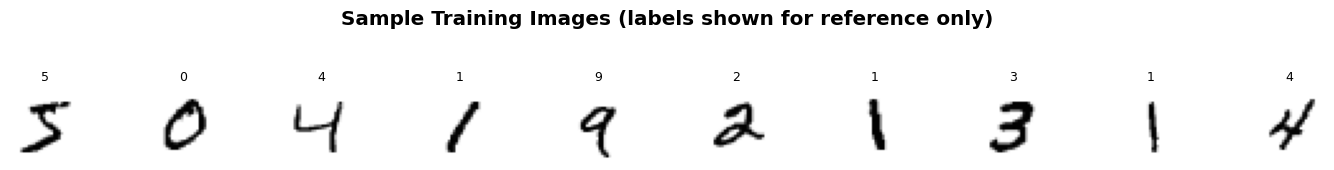

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 784).astype('float32') / 255.0
print(f'Training set: {x_train.shape}  (labels ignored during VAE training)')
print(f'Test set:     {x_test.shape}')

# Preview a row of training digits
fig, axes = plt.subplots(1, 10, figsize=(14, 1.5))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(str(y_train[i]), fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images (labels shown for reference only)',
             fontweight='bold', y=1.12)
plt.tight_layout()
plt.show()

---
# 3. VAE Architecture

## 3.1 Design choices

We use a **fully-connected** (dense) encoder and decoder, matching the feedforward
network style from the companion notebook. For MNIST, this works well;
convolutional architectures give better quality but add architectural complexity.

| Component | Layers | Output |
|---|---|---|
| Encoder | Dense(256, ReLU) → Dense(128, ReLU) | $\boldsymbol{\mu}$, $\log\boldsymbol{\sigma}^2 \in \mathbb{R}^d$ |
| Sampling | Reparameterization trick | $\mathbf{z} \in \mathbb{R}^d$ |
| Decoder | Dense(128, ReLU) → Dense(256, ReLU) → Dense(784, sigmoid) | $\hat{\mathbf{x}} \in [0,1]^{784}$ |

**Try:** `latent_dim = 2` for visualizations; `latent_dim = 16` for
noticeably sharper generated images.

In [3]:
# @title VAE — Hyperparameters
latent_dim = 2    # @param {type:"integer"}  -- try 2 (visualization) or 16 (quality)
hidden_dim = 256  # @param {type:"integer"}
kl_weight  = 1.0  # @param {type:"number"}   -- try 0.1, 1.0, 5.0
n_epochs   = 30   # @param {type:"integer"}
batch_size = 128  # @param {type:"integer"}

# --- Encoder ---
enc_input = keras.Input(shape=(784,))
h = layers.Dense(hidden_dim, activation='relu')(enc_input)
h = layers.Dense(hidden_dim // 2, activation='relu')(h)
z_mean    = layers.Dense(latent_dim, name='z_mean')(h)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(h)

# --- Reparameterization ---
class Sampling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(seed=42)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = keras.random.normal(shape=ops.shape(z_mean), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * eps

z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(enc_input, [z_mean, z_log_var, z], name='encoder')

# --- Decoder ---
dec_input = keras.Input(shape=(latent_dim,))
h = layers.Dense(hidden_dim // 2, activation='relu')(dec_input)
h = layers.Dense(hidden_dim, activation='relu')(h)
dec_output = layers.Dense(784, activation='sigmoid')(h)  # pixel values in [0, 1]
decoder = keras.Model(dec_input, dec_output, name='decoder')

# --- VAE ---
class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder   = encoder
        self.decoder   = decoder
        self.kl_weight = kl_weight
        self.total_loss_tracker = keras.metrics.Mean(name='total_loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, x, training=False):
        z_mean, z_log_var, z = self.encoder(x, training=training)
        x_recon = self.decoder(z, training=training)
        return x_recon, z_mean, z_log_var

    def compute_loss(self, x, y, y_pred, sample_weight, training=True):
        x_recon, z_mean, z_log_var = y_pred
        # Binary cross-entropy reconstruction loss (summed over 784 pixels, averaged over batch)
        recon_loss = ops.mean(ops.sum(
            -x * ops.log(x_recon + 1e-8) - (1 - x) * ops.log(1 - x_recon + 1e-8),
            axis=1))
        kl_loss = -0.5 * ops.mean(ops.sum(
            1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=1))
        total_loss = recon_loss + self.kl_weight * kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return total_loss

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

---
# 4. Training

We compile with `loss=None` because the entire ELBO loss is defined inside
`compute_loss`. The JAX backend handles gradient computation automatically.
With `jit_compile=False` the first epoch is slightly slower, but there are no
JIT-tracing surprises for a course notebook.

In [ ]:
vae = VAE(encoder, decoder, kl_weight=kl_weight)
vae.compile(optimizer=keras.optimizers.Adam(1e-3), loss=None, jit_compile=False)
history = vae.fit(x_train, epochs=n_epochs, batch_size=batch_size, verbose=1)

print(f'Final  total loss : {history.history["total_loss"][-1]:.2f}')
print(f'       recon loss : {history.history["recon_loss"][-1]:.2f}')
print(f'       KL loss    : {history.history["kl_loss"][-1]:.2f}')

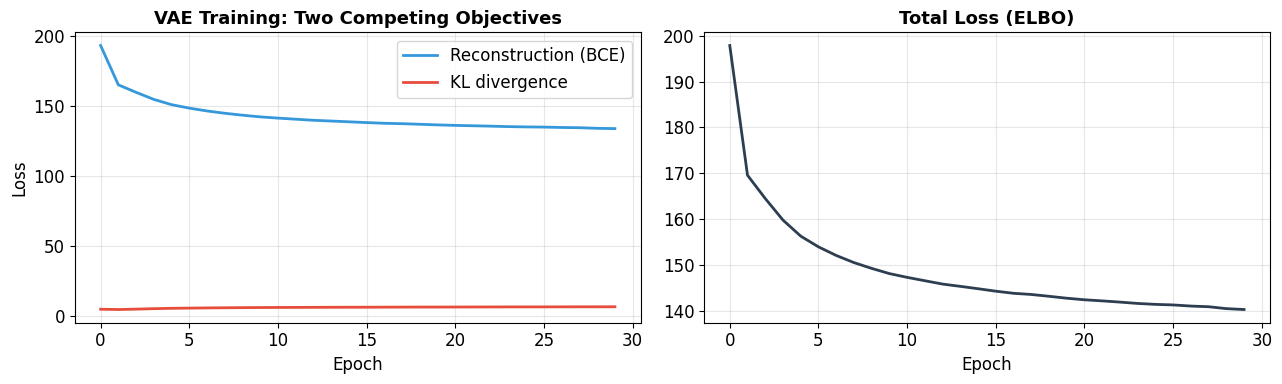

In [5]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['recon_loss'], color='#3498db', linewidth=2,
             label='Reconstruction (BCE)')
axes[0].plot(history.history['kl_loss'], color='#e74c3c', linewidth=2,
             label='KL divergence')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('VAE Training: Two Competing Objectives', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['total_loss'], color='#2c3e50', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_title('Total Loss (ELBO)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 5. Reconstruction and Generation

## 5.1 Reconstructions

We encode test images to latent codes $\hat{\mathbf{z}}$, then decode them back.
Good reconstructions confirm the model has learned a meaningful latent representation.

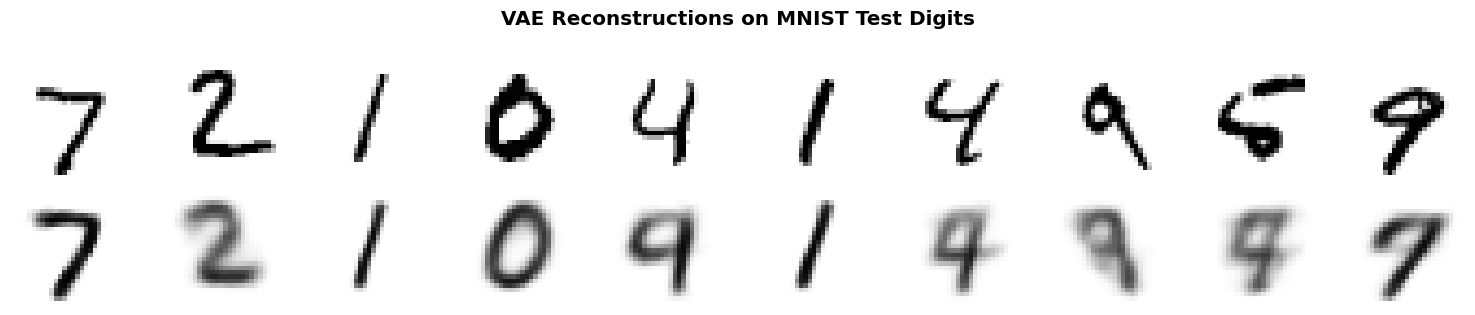

In [6]:
n_show = 10
z_mean_t, _, z_t = encoder.predict(x_test[:n_show], verbose=0)
x_recon_t = np.array(decoder.predict(np.array(z_t), verbose=0))

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.5, 3.2))
for i in range(n_show):
    axes[0, i].imshow(x_test[i].reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon_t[i].reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10, fontweight='bold', rotation=0,
                       ha='right', va='center')
axes[1, 0].set_ylabel('Recon.', fontsize=10, fontweight='bold', rotation=0,
                       ha='right', va='center')
plt.suptitle('VAE Reconstructions on MNIST Test Digits', fontweight='bold')
plt.tight_layout()
plt.show()

## 5.2 Generating new digits

To *generate* (not reconstruct), we skip the encoder entirely:
sample $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, I_d)$ directly from the prior and decode.

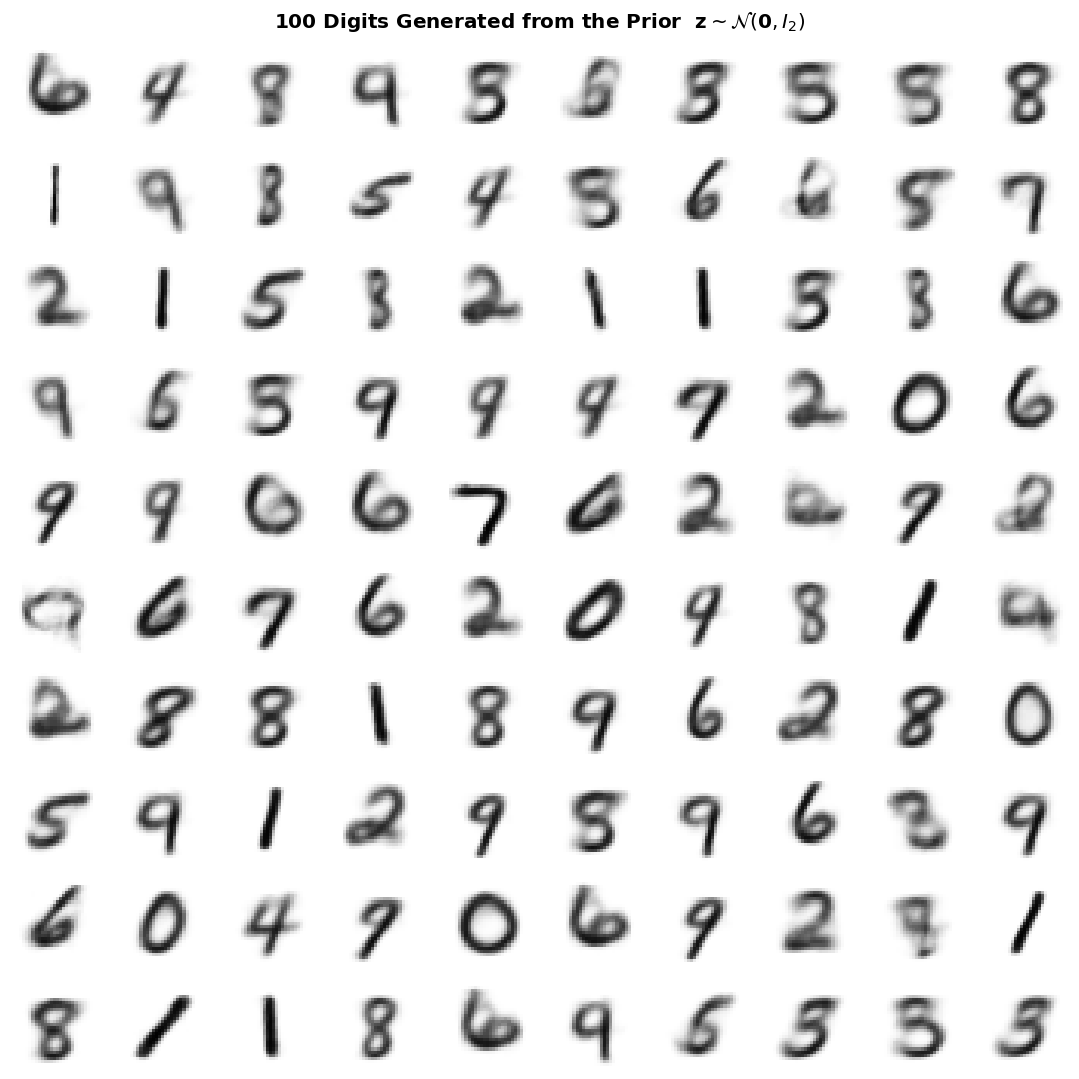

In [7]:
n_gen = 100
z_gen = np.random.randn(n_gen, latent_dim).astype(np.float32)
x_gen = np.array(decoder.predict(z_gen, verbose=0))

fig, axes = plt.subplots(10, 10, figsize=(11, 11))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_gen[i].reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle(
    f'100 Digits Generated from the Prior  '
    r'$\mathbf{z}\sim\mathcal{N}(\mathbf{0},I_{' + str(latent_dim) + r'})$',
    fontweight='bold')
plt.tight_layout()
plt.show()

## 5.3 Latent space (for `latent_dim = 2`)

With a 2-D latent space we can plot exactly where each test digit lands,
and decode an entire grid of $\mathbf{z}$ values to see how the VAE
organizes the digit manifold.

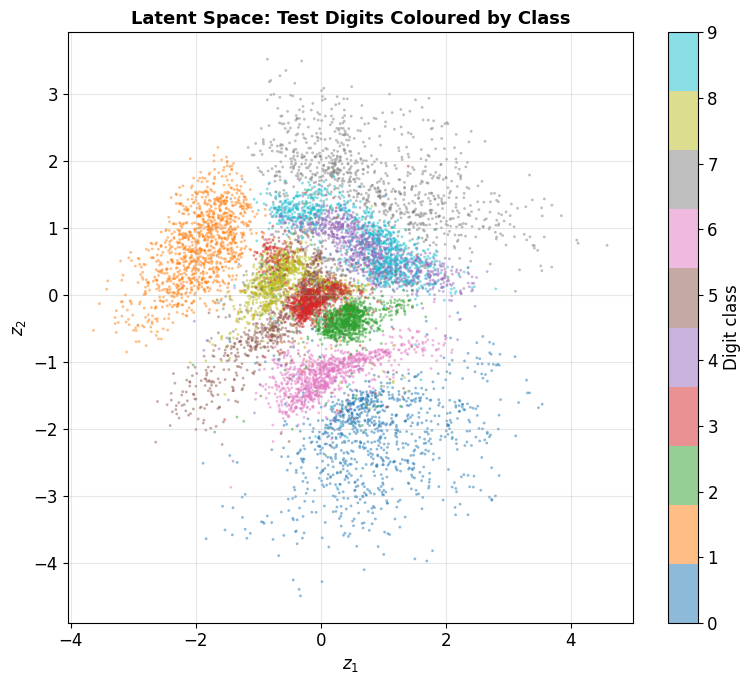

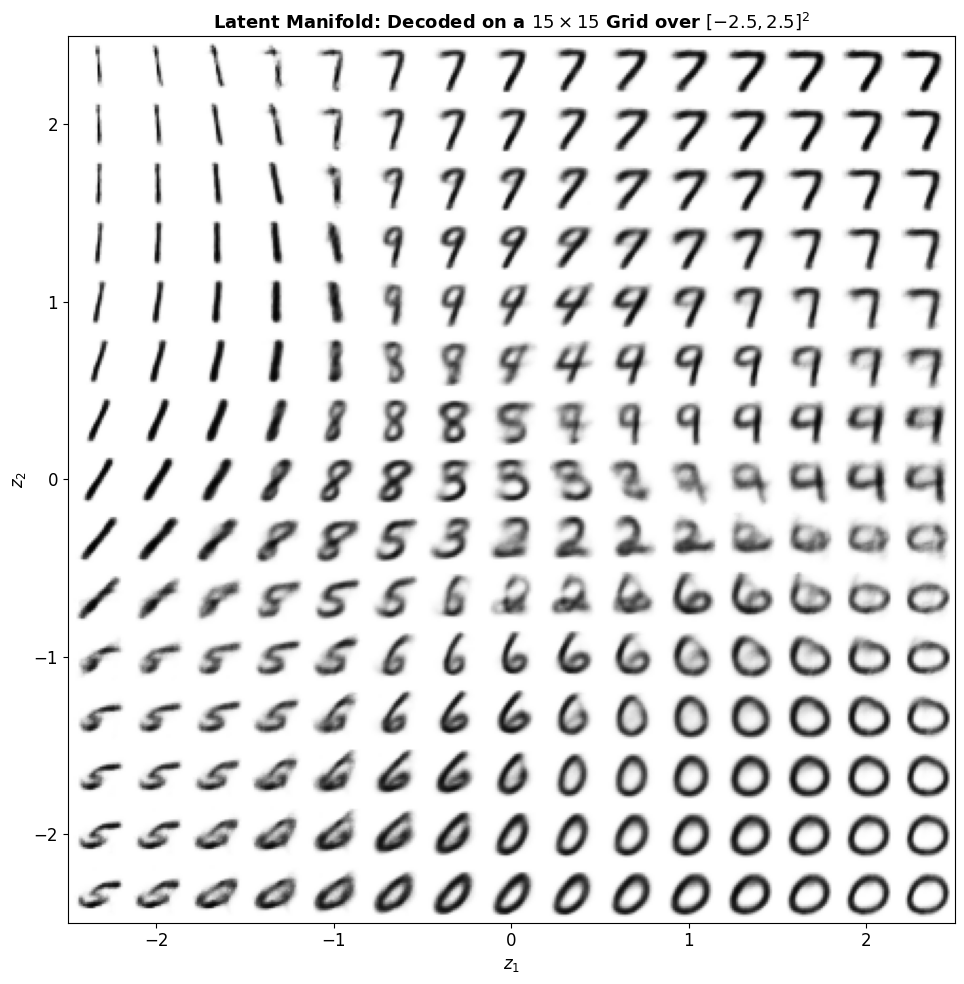

In [8]:
if latent_dim == 2:
    # Encode the full test set and colour by digit class
    z_mean_all, _, _ = encoder.predict(x_test, verbose=0)
    z_mean_all = np.array(z_mean_all)

    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(z_mean_all[:, 0], z_mean_all[:, 1],
                    c=y_test, cmap='tab10', s=4, alpha=0.5, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Digit class', ticks=range(10))
    ax.set_title('Latent Space: Test Digits Coloured by Class', fontweight='bold')
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Decode a uniform grid over the prior support
    n_grid, z_range = 15, 2.5
    canvas = np.zeros((28 * n_grid, 28 * n_grid))
    grid_x = np.linspace(-z_range, z_range, n_grid)
    grid_y = np.linspace(-z_range, z_range, n_grid)
    z_pts = np.array([[xi, yi] for yi in grid_y[::-1] for xi in grid_x],
                      dtype=np.float32)
    decoded = np.array(decoder.predict(z_pts, verbose=0))
    for k, img in enumerate(decoded):
        row, col = divmod(k, n_grid)
        canvas[row*28:(row+1)*28, col*28:(col+1)*28] = img.reshape(28, 28)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(canvas, cmap='gray_r',
              extent=[-z_range, z_range, -z_range, z_range], origin='upper')
    ax.set_title(r'Latent Manifold: Decoded on a $15\times15$ Grid over $[-2.5, 2.5]^2$',
                 fontweight='bold')
    ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
    plt.tight_layout()
    plt.show()
else:
    print(f'Latent space plot requires latent_dim=2 (current: {latent_dim}).')
    print('Re-run the architecture cell with latent_dim=2 to see this visualization.')

---
# 6. Exercises

> **Exercise 6.1.** *(KL-weight tradeoff on MNIST)*
> Train the VAE with `kl_weight` set to each of `0.05`, `0.5`, `1.0`, and `5.0`.
> For each value, inspect the reconstruction quality and the generated samples.
>
> **(a)** At what `kl_weight` do the reconstructions look sharpest? Why?
>
> **(b)** At what value do the generated samples look most like real digits? Why does
> the answer differ from **(a)**?
>
> **(c)** Describe qualitatively what happens to the 2-D latent scatter plot as
> `kl_weight` increases. What prior distribution is the model being pushed toward?

> **Exercise 6.2.** *(Latent dimension and reconstruction quality)*
> Set `latent_dim` to `2`, `8`, and `32` and compare the final reconstruction loss.
>
> **(a)** Plot the first 10 reconstructions for each `latent_dim`. At what dimension
> do digits become clearly recognizable? At what point do further increases give
> diminishing returns?
>
> **(b)** For `latent_dim = 32`, can you still generate coherent digits from a random
> prior sample? Why or why not?

> **Exercise 6.3.** *(Unsupervised structure in the latent space)*
> With `latent_dim = 2`, the latent space scatter plot (§5.3) colours each point by
> its true digit class — but **the VAE never saw these labels during training**.
>
> **(a)** Are different digit classes separated in the latent space? Discuss why
> clustering might emerge even without supervision.
>
> **(b)** Pick two neighboring clusters (e.g. `4` and `9`). Decode a straight
> line of 8 points connecting a typical code for each digit. What do you observe?
> What does smooth interpolation tell you about the latent geometry?

> **Exercise 6.4.** *(BCE vs. MSE reconstruction loss)*
> Replace the binary cross-entropy reconstruction loss in `compute_loss` with mean
> squared error:
> $$\mathcal{L}_{\text{recon}}^{\text{MSE}} =
>   \sum_{i=1}^{784}(x_i - \hat{x}_i)^2.$$
> Retrain and compare reconstructions and samples.
>
> **(a)** Which loss produces sharper or blurrier reconstructions? Explain why
> MSE tends to produce blurrier outputs.
>
> **(b)** In the probabilistic derivation of the ELBO, what distributional
> assumption on $p_\theta(\mathbf{x}|\mathbf{z})$ corresponds to BCE?
> What assumption corresponds to MSE?

> **Exercise 6.5.** *(Comparing generative and discriminative models)*
> The [feedforward MNIST classifier](intro_feedforward_mnist.ipynb) achieves
> $\approx 98\%$ test accuracy on digit recognition.
>
> **(a)** Could you use the trained VAE for digit classification? Sketch a
> procedure using Bayes' rule and the learned decoder.
> Would you expect it to compete with the dedicated classifier? Why or why not?
>
> **(b)** A key asymmetry: the classifier requires **labels** for every
> training image; the VAE uses **none**. Give a scenario where the VAE's
> unsupervised nature would be a significant practical advantage.